In [15]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ahmedhamada0/brain-tumor-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-detection' dataset.
Path to dataset files: /kaggle/input/brain-tumor-detection


In [16]:
import os

print("Dataset path:", path)
print("Folders/files inside dataset:")
print(os.listdir(path))

Dataset path: /kaggle/input/brain-tumor-detection
Folders/files inside dataset:
['no', 'yes', 'Br35H-Mask-RCNN', 'pred']


In [ ]:
yes_path = os.path.join(path, "yes")   # tumor images
no_path = os.path.join(path, "no")     # no tumor images

yes_images = os.listdir(yes_path)
no_images = os.listdir(no_path)

print("Tumor images:", len(yes_images))
print("No tumor images:", len(no_images))
print("Total binary classification images:", len(yes_images) + len(no_images))

Tumor images: 1500
No tumor images: 1500
Total binary classification images: 3000


Tumor image size: (353, 442)
No tumor image size: (201, 251)


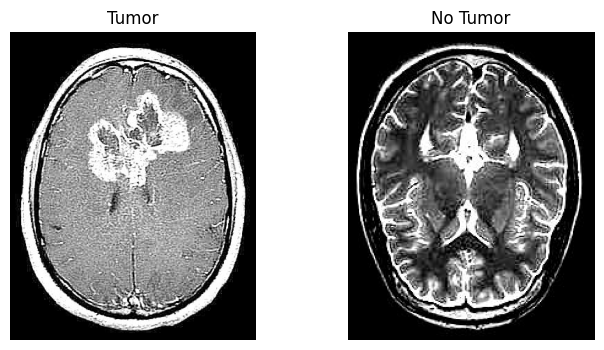

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select one image from each class
sample_yes = os.path.join(yes_path, yes_images[0])
sample_no = os.path.join(no_path, no_images[0])

img_yes = Image.open(sample_yes)
img_no = Image.open(sample_no)

print("Tumor image size:", img_yes.size)
print("No tumor image size:", img_no.size)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_yes, cmap="gray")
plt.title("Tumor")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_no, cmap="gray")
plt.title("No Tumor")
plt.axis("off")

plt.show()

In [ ]:
import shutil

clean_dir = "/content/brain_tumor_binary"

# Remove old clean folder if it already exists
if os.path.exists(clean_dir):
    shutil.rmtree(clean_dir)

# Create clean class folders
os.makedirs(os.path.join(clean_dir, "tumor"))
os.makedirs(os.path.join(clean_dir, "no_tumor"))

# Copy images into clean folders
for img in yes_images:
    shutil.copy(os.path.join(yes_path, img), os.path.join(clean_dir, "tumor", img))

for img in no_images:
    shutil.copy(os.path.join(no_path, img), os.path.join(clean_dir, "no_tumor", img))

print("Clean dataset created successfully!")
print("Tumor images:", len(os.listdir(os.path.join(clean_dir, "tumor"))))
print("No tumor images:", len(os.listdir(os.path.join(clean_dir, "no_tumor"))))
print("Clean dataset path:", clean_dir)

Clean dataset created successfully!
Tumor images: 1500
No tumor images: 1500
Clean dataset path: /content/brain_tumor_binary


In [ ]:
import os
import shutil
import random

# Clean binary dataset path from previous step
source_dir = "/content/brain_tumor_binary"

# New split dataset folder
split_dir = "/content/brain_tumor_split"

# Remove old split folder if exists
if os.path.exists(split_dir):
    shutil.rmtree(split_dir)

# Create train, validation, test folders
classes = ["tumor", "no_tumor"]
splits = ["train", "val", "test"]

for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(split_dir, split, cls))

# Split ratio: 70% train, 15% validation, 15% test
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

random.seed(42)

for cls in classes:
    class_path = os.path.join(source_dir, cls)
    images = os.listdir(class_path)
    random.shuffle(images)

    total = len(images)
    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    for img in train_images:
        shutil.copy(os.path.join(class_path, img), os.path.join(split_dir, "train", cls, img))

    for img in val_images:
        shutil.copy(os.path.join(class_path, img), os.path.join(split_dir, "val", cls, img))

    for img in test_images:
        shutil.copy(os.path.join(class_path, img), os.path.join(split_dir, "test", cls, img))

print("Dataset split completed successfully!")

for split in splits:
    print("\n", split.upper())
    for cls in classes:
        print(cls, ":", len(os.listdir(os.path.join(split_dir, split, cls))))

Dataset split completed successfully!

 TRAIN
tumor : 1050
no_tumor : 1050

 VAL
tumor : 225
no_tumor : 225

 TEST
tumor : 225
no_tumor : 225


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# Improve dataset loading performance
AUTOTUNE = tf.data.AUTOTUNE

# Define the path to the split dataset
split_dir = "/content/brain_tumor_split"

# Load image datasets
train_data = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_dir, "train"),
    labels="inferred",
    label_mode="binary",
    image_size=(224, 224),
    interpolation="nearest",
    batch_size=32,
    shuffle=True
)

val_data = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_dir, "val"),
    labels="inferred",
    label_mode="binary",
    image_size=(224, 224),
    interpolation="nearest",
    batch_size=32,
    shuffle=False
)

test_data = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_dir, "test"),
    labels="inferred",
    label_mode="binary",
    image_size=(224, 224),
    interpolation="nearest",
    batch_size=32,
    shuffle=False
)

train_data = train_data.prefetch(buffer_size=AUTOTUNE)
val_data = val_data.prefetch(buffer_size=AUTOTUNE)
test_data = test_data.prefetch(buffer_size=AUTOTUNE)

# Data augmentation to reduce overfitting
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

# Build custom CNN model
cnn_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Normalize pixel values from 0-255 to 0-1
    layers.Rescaling(1./255),

    # Apply data augmentation
    data_augmentation,

    # Convolution block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Fully connected classification layers
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

# Compile the CNN model
cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Display model architecture
cnn_model.summary()

# Early stopping to reduce overfitting
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train the custom CNN model
history_cnn = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop]
)

Found 2100 files belonging to 2 classes.
Found 450 files belonging to 2 classes.
Found 450 files belonging to 2 classes.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 355s 5s/step - accuracy: 0.7043 - loss: 0.6108 - val_accuracy: 0.7933 - val_loss: 0.4682
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 276s 4s/step - accuracy: 0.7557 - loss: 0.5274 - val_accuracy: 0.8222 - val_loss: 0.4361
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 279s 4s/step - accuracy: 0.7729 - loss: 0.4876 - val_accuracy: 0.8533 - val_loss: 0.3466
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 311s 4s/step - accuracy: 0.7976 - loss: 0.4350 - val_accuracy: 0.8711 - val_loss: 0.2912
Epoch 5/15
36/66 ━━━━━━━━━━━━━━━━━━━━ 2:05 4s/step - accuracy: 0.7940 - loss: 0.4471

In [ ]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Custom CNN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss graph
plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('Custom CNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Evaluate model on test data
test_loss, test_accuracy = cnn_model.evaluate(test_data)

print("Custom CNN Test Accuracy:", test_accuracy)
print("Custom CNN Test Loss:", test_loss)

# Get true labels
y_true = np.concatenate([y.numpy() for x, y in test_data], axis=0).astype(int).reshape(-1)

# Get predicted probabilities
y_pred_prob = cnn_model.predict(test_data)

# Convert probabilities to class labels
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

# Classification report
print("Classification Report for Custom CNN:")
print(classification_report(y_true, y_pred, target_names=["No Tumor", "Tumor"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Tumor", "Tumor"]
)

disp.plot()
plt.title("Custom CNN Confusion Matrix")
plt.show()

# Store metrics for later comparison
cnn_accuracy = accuracy_score(y_true, y_pred)
cnn_precision = precision_score(y_true, y_pred)
cnn_recall = recall_score(y_true, y_pred)
cnn_f1 = f1_score(y_true, y_pred)

print("Custom CNN Metrics")
print("Accuracy:", cnn_accuracy)
print("Precision:", cnn_precision)
print("Recall:", cnn_recall)
print("F1-score:", cnn_f1)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Load pre-trained MobileNetV2 model without top classification layer
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze base model layers
base_model.trainable = False

# Build transfer learning model
mobilenet_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Preprocessing required for MobileNetV2
    layers.Lambda(preprocess_input),

    # Pre-trained base model
    base_model,

    # Classification head
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

# Compile model
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Show model summary
mobilenet_model.summary()

# Early stopping
early_stop_mobile = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train MobileNetV2 model
history_mobile = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop_mobile]
)

In [ ]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(history_mobile.history['accuracy'], label='Training Accuracy')
plt.plot(history_mobile.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2 Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss graph
plt.figure(figsize=(8, 5))
plt.plot(history_mobile.history['loss'], label='Training Loss')
plt.plot(history_mobile.history['val_loss'], label='Validation Loss')
plt.title('MobileNetV2 Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Evaluate model on test data
mobile_test_loss, mobile_test_accuracy = mobilenet_model.evaluate(test_data)

print("MobileNetV2 Test Accuracy:", mobile_test_accuracy)
print("MobileNetV2 Test Loss:", mobile_test_loss)

# True labels
y_true_mobile = np.concatenate([y.numpy() for x, y in test_data], axis=0).astype(int).reshape(-1)

# Predicted probabilities
y_pred_prob_mobile = mobilenet_model.predict(test_data)

# Convert probabilities into class labels
y_pred_mobile = (y_pred_prob_mobile > 0.5).astype(int).reshape(-1)

# Classification report
print("Classification Report for MobileNetV2:")
print(classification_report(y_true_mobile, y_pred_mobile, target_names=["No Tumor", "Tumor"]))

# Confusion matrix
cm_mobile = confusion_matrix(y_true_mobile, y_pred_mobile)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mobile,
    display_labels=["No Tumor", "Tumor"]
)

disp.plot()
plt.title("MobileNetV2 Confusion Matrix")
plt.show()

# Store metrics for comparison table
mobile_accuracy = accuracy_score(y_true_mobile, y_pred_mobile)
mobile_precision = precision_score(y_true_mobile, y_pred_mobile)
mobile_recall = recall_score(y_true_mobile, y_pred_mobile)
mobile_f1 = f1_score(y_true_mobile, y_pred_mobile)

print("MobileNetV2 Metrics")
print("Accuracy:", mobile_accuracy)
print("Precision:", mobile_precision)
print("Recall:", mobile_recall)
print("F1-score:", mobile_f1)

In [ ]:
import pandas as pd

# Create comparison table
comparison_table = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2"],
    "Accuracy": [cnn_accuracy, mobile_accuracy],
    "Precision": [cnn_precision, mobile_precision],
    "Recall": [cnn_recall, mobile_recall],
    "F1-score": [cnn_f1, mobile_f1]
})

# Round values for clean presentation
comparison_table = comparison_table.round(4)

print("Final Comparison Table:")
display(comparison_table)

In [ ]:
import matplotlib.pyplot as plt

comparison_table.set_index("Model").plot(kind="bar", figsize=(9, 5))

plt.title("Performance Comparison: Custom CNN vs MobileNetV2")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y")
plt.show()

In [ ]:
# Save Custom CNN model
cnn_model.save("/content/custom_cnn_brain_tumor_model.h5")

# Save MobileNetV2 model
mobilenet_model.save("/content/mobilenetv2_brain_tumor_model.h5")

print("Both models saved successfully!")

In [ ]:
from google.colab import files

files.download("/content/custom_cnn_brain_tumor_model.h5")
files.download("/content/mobilenetv2_brain_tumor_model.h5")